In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import json
import matplotlib.image as image
import pickle

In [11]:
sys.path.insert(1, './utils/')

In [12]:
save = True
show = True
network = 'M2'
save_name = f'../Figures/Figure_s4'
image_format = "png"
dpi = 300


In [13]:
# from load_data import *
# from plot_functions import *
from utils_functions import *

# Luminance Simulations


In [14]:
fn = 12



simulation_intensity = load_dict(f'../output/params_final_nonlin/simulation_osr_intensity.pickle')
simulation_duration = load_dict(f'../output/params_final_nonlin/simulation_osr_duration.pickle')
simulation_dynamic = load_dict(f'../output/params_final_nonlin/simulation_osr_{fn}.pickle')



circuit_scheme = image.imread(f'schemes/scheme_{network}.png')


## Load Simulation Results

In [15]:
simulation_dynamic['simulations']['6_Hz']['stimulus']

array([0., 0., 0., ..., 0., 0., 0.])

In [16]:

    
keys = ['6_Hz', '10_Hz', '12_Hz']

frequencies = simulation_dynamic['osrparams']['frequencies']
periods = np.round(1/frequencies,2)*1000

times = [simulation_dynamic['simulations'][key]['time']-simulation_dynamic['simulations'][key]['lastflash_tp']
         for key in keys]

times_duration= [simulation_duration['simulations'][key]['time']-simulation_duration['simulations'][key]['lastflash_tp']
         for key in keys]

stims_dynamic = [simulation_dynamic['simulations'][key]['stimulus'] for key in keys]
stims_duration = [simulation_duration['simulations'][key]['stimulus'] for key in keys]
stims_intensity = [simulation_intensity['simulations'][key]['stimulus'] for key in keys]
#time2 = simulation2['simulations'][key]['time']

flashes =[np.where(np.diff(simulation_dynamic['simulations'][key]['stimulus']) != 0)[0].tolist() for key in keys]

lastflashends = [simulation_dynamic['simulations'][key]['lastflash_tp'] for key in keys]
#lastflashend2 = simulation2['simulations'][key]['lastflash_tp']


# simulation dynamic
responses_dynamic = [simulation_dynamic['simulations'][key]['RG'] for key in keys]
delays_dynamic = [simulation_dynamic['simulations'][key]['delay'] for key in keys]
peak_amps_dynamic = [simulation_dynamic['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_dynamic = simulation_dynamic['delays']*1000
slope_dynamic = simulation_dynamic['slope']
offset_dynamic =  simulation_dynamic['offset']*1000 

delays_all_dynamic_relative = delays_all_dynamic - delays_all_dynamic[-1]
offset_dynamic_relative =  simulation_dynamic['offset']*1000 - delays_all_dynamic[-1]

# simulation intensity
responses_intensity = [simulation_intensity['simulations'][key]['RG'] for key in keys]
delays_intensity = [simulation_intensity['simulations'][key]['delay'] for key in keys]
peak_amps_intensity = [simulation_intensity['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_intensity = simulation_intensity['delays']*1000
slope_intensity = simulation_intensity['slope']
offset_intensity =  simulation_intensity['offset']*1000

delays_all_intensity_relative = delays_all_intensity - delays_all_dynamic[-1]
offset_intensity_relative =  simulation_intensity['offset']*1000 - delays_all_dynamic[-1]



# simulation duration
responses_duration = [simulation_duration['simulations'][key]['RG'] for key in keys]
delays_duration = [simulation_duration['simulations'][key]['delay'] for key in keys]
peak_amps_duration = [simulation_duration['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_duration = simulation_duration['delays']*1000
slope_duration = simulation_duration['slope']
offset_duration =  simulation_duration['offset']*1000

delays_all_duration_relative = delays_all_duration - delays_all_dynamic[-1]
offset_duration_relative =  simulation_duration['offset']*1000 - delays_all_dynamic[-1]

# load circuit image


omitted_flashstarts = [0.16-0.04, 0.10-0.04, 0.06-0.04]
omitted_flashends = [i+0.04 for i in omitted_flashstarts]

# Plot without scheme and barplot

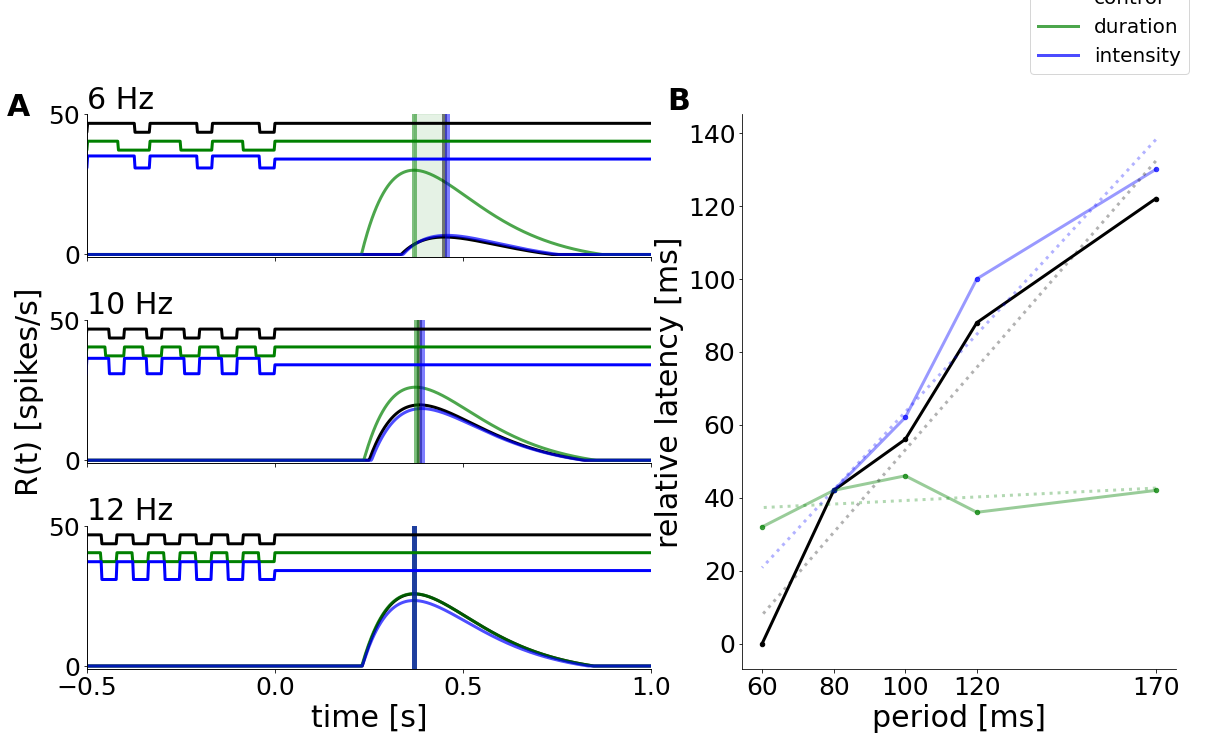

In [17]:
#figure parameter

fontsize_legend = 20
fontsize_labels = 30
fontsize_panellabel = 30
fontsize_ticks = 25
lw = 3
ms = 20
panellabel_position = [-0.2, 1.15]
frequencytext_position = [0.15,1.1]
figsize_ratio = 5
nrows = 3
ncols = 9

# figsize = (ncols*figsize_ratio, nrows*figsize_ratio)
figsize = (18,10)


cond_labels = ["control", "duration", "intensity"]

    
frequencies_displayed = [6,10,12]
    
color_control = "k"
color_test = "green"
color_test2 = "blue"
alpha_test = .7

#initialize figure
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(nrows,ncols)
fig.tight_layout()

fig.patch.set_facecolor('white')


fig.subplots_adjust(top=0.88,
bottom=0.11,
left=0.11,
right=0.95,
hspace=0.44,
wspace=2.3)


#####################################################################################################################
# create panels
#####################################################################################################################


B = fig.add_subplot(gs[0,0:-4], frameon = False)
B0 = fig.add_subplot(gs[0,0:-4])
B1 = fig.add_subplot(gs[1,0:-4], sharey = B0, sharex = B0)
B2 = fig.add_subplot(gs[2,0:-4], sharey = B0, sharex = B0)

C = fig.add_subplot(gs[:,-4:])
#C.set_box_aspect(1)


    
#####################################################################################################################
# PANEL B
#####################################################################################################################

if "B" in globals():
    ax = B
    ax.text(panellabel_position[0]+0.1,panellabel_position[1], 'A', transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    ax.set_xticks([])
    ax.set_yticks([])

    
#####################################################################################################################
# COMMON TO SUBPANELS B0,B1,B2
#####################################################################################################################
index_frequencies_to_show = [0,2,4]
    
for index, ax in enumerate([B0,B1,B2]):
    
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(f'{frequencies_displayed[index]} Hz',fontsize = fontsize_labels, loc = 'left')
    
    if ax == B0:
        ax.plot(times[index],responses_dynamic[index], color = 'black', linewidth = lw, label = cond_labels[0])
        ax.plot(times_duration[index],responses_duration[index], color = color_test, alpha=.7, linewidth = lw, label = cond_labels[1])
        ax.plot(times[index],responses_intensity[index], color = color_test2, alpha=.7, linewidth = lw, label = cond_labels[2])
    else:
        ax.plot(times[index],responses_dynamic[index], color = 'black', linewidth = lw)
        ax.plot(times_duration[index],responses_duration[index], color = color_test, alpha=.7, linewidth = lw)
        ax.plot(times[index],responses_intensity[index], color = color_test2, alpha=.7, linewidth = lw)
    
   
            
    ax.locator_params(axis='y', nbins=3)
    ax.set_xlim(-.5,1)
    ax.set_ylim(-1,50)
    
    # plot max and span
#     ax.scatter(delays_dynamic[index],peak_amps_dynamic[index], color = 'k')
#     ax.scatter(delays_duration[index],peak_amps_duration[index], color = 'grey')

    ax.axvline(delays_dynamic[index], color = 'k', alpha = .5, linewidth = 5 )
    ax.axvline(delays_duration[index], color = color_test, alpha = .5,linewidth = 5)
    ax.axvline(delays_intensity[index], color = color_test2, alpha = .5,linewidth = 5)

    ax.axvspan(delays_dynamic[index],delays_duration[index], color = color_test, alpha = 0.1)
    #ax.axvspan(delays_dynamic[index],delays_intensity[index], color = color_test2, alpha = 0.1)
    ax.locator_params(axis='x', nbins=3)
    ax.locator_params(axis='y', nbins=2)


    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)

        #ax2 = A2s
    ax2 = ax.twinx()

    stim0 = stims_dynamic[index]
    stim1 = stims_duration[index] -2
    stim2 = stims_intensity[index]-4
    ax2.plot(times[index],stim0, color = 'black', linewidth = lw)
    ax2.plot(times_duration[index],stim1, color = color_test, linewidth = lw)
    ax2.plot(times[index],stim2, color = color_test2, linewidth = lw)
    ax2.set_ylim(-15,1)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.set_yticks([])
    ax2.tick_params('y', labelright = False)

#####################################################################################################################
# SUBPANEL B0 specific
#####################################################################################################################

ax = B0

ax.tick_params('x', labelbottom=False)
    
#####################################################################################################################
# SUBPANEL B1
#####################################################################################################################

ax = B1
ax.tick_params('x', labelbottom=False)
ax.set_ylabel('R(t) [spikes/s]',fontsize = fontsize_labels)

    
#####################################################################################################################
# SUBPANEL B2
#####################################################################################################################

ax = B2
ax.set_xlabel('time [s]',fontsize = fontsize_labels)


#####################################################################################################################
# PANEL C
#####################################################################################################################
if "C" in globals():
    ax = C
    ax.text(panellabel_position[0]+0.08,panellabel_position[1]-.1, 'B', transform=ax.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    
    ax.set_ylabel('relative latency [ms]', fontsize = fontsize_labels)
    ax.set_xlabel('period [ms]', fontsize = fontsize_labels)
    
    ax.set_xticks(periods[::-1])
    
    
    ax.plot(periods,delays_all_dynamic_relative,color = 'black',linewidth = lw)
    ax.scatter(periods,delays_all_dynamic_relative, color = 'black', s = ms)

    ax.plot(periods,delays_all_duration_relative,color = color_test, alpha=.4,linewidth = lw)
    ax.scatter(periods,delays_all_duration_relative, color = color_test, alpha=.7, s = ms)

    ax.plot(periods[:-1],delays_all_intensity_relative,color = color_test2, alpha=.4,linewidth = lw)
    ax.scatter(periods[:-1],delays_all_intensity_relative, color = color_test2, alpha=.7, s = ms)

    # slope fit 
    ax.plot(periods,slope_fun(periods,slope_duration,offset_duration_relative),
           color = color_test,linestyle = ':',linewidth = lw,alpha = 0.3)
    ax.plot(periods,slope_fun(periods,slope_intensity,offset_intensity_relative),
           color = color_test2,linestyle = ':',linewidth = lw,alpha = 0.3)
#            label = f'slope: {slope_duration:.2f}')
    ax.plot(periods,slope_fun(periods,slope_dynamic,offset_dynamic_relative),
           color = 'black',linestyle = ':',linewidth = lw,alpha = 0.3)
#            label = f'slope: {slope_dynamic:.2f}')


#     ax.legend(fontsize = fontsize_legend)
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)

    
#####################################################################################################################
# LEGEND
#####################################################################################################################
     
fig.legend(fontsize = fontsize_legend,loc=(.85,.9))
 
#####################################################################################################################
# SAVE AND PLOT
#####################################################################################################################

if save:   
    plt.savefig("{}.{}".format(save_name, image_format))
if show:
    plt.show()
else:
    plt.close()

In [18]:
print(f'slope control : {slope_dynamic}')
print(f'slope duration : {slope_duration}')
print(f'slope intensity : {slope_intensity}')

slope control : 1.1315021425086438
slope duration : 0.048669532657955566
slope intensity : 1.0667841451194533


# 